# **Notebook 01 - Análise Exploratória Dataset (dados_ipdm.csv):**

In [11]:
# *********** AVISO!!!!! ************

# Se for a primeira vez rodando, remova o '#' das linhas abaixo:

# install.packages(
#     c("glue", 
#       "dplyr", 
#       "tidyverse"))

In [12]:
library(glue)

usuario <- 'Megalonnix'
repositorio <- 'Projeto_Integrador_PI3_2Sem_2026'
nm_dataset_usado <- 'dados_ipdm.csv'

# 1. Cria a URL correta com o "raw." no início e a barra antes do usuário
URL_GITHUB <- glue(
'https://raw.githubusercontent.com/{usuario}/{repositorio}/main/{nm_dataset_usado}')

# 2. Lê o arquivo CSV diretamente da internet
df <- read.csv(URL_GITHUB, sep = ";", dec = ",", fileEncoding = 'Latin1')


In [13]:
# ---------------------------------------------------------
# BLOCO 1: Nomes das colunas e Tipos de Dados
# ---------------------------------------------------------

# Lista apenas os nomes das colunas
cat("--- LISTA DE COLUNAS ---\n")
print(colnames(df))

# Exibe a estrutura completa (Nome da coluna, Tipo de dado e Amostra dos valores)
cat("\n--- ESTRUTURA E TIPOS DE DADOS ---\n")
library(dplyr)
glimpse(df)

--- LISTA DE COLUNAS ---
 [1] "cod_ibge"     "Municipio"    "Valor"        "Ano"          "Tipo"        
 [6] "Valor.Estado" "Indicador.1"  "Indicador.2"  "Indicador.3"  "Indicador.4" 
[11] "Indicador.5"  "X"           

--- ESTRUTURA E TIPOS DE DADOS ---
Rows: 61,920
Columns: 12
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…

In [14]:
df <- df %>% select(-X)
glimpse(df)

Rows: 61,920
Columns: 11
$ cod_ibge     <int> 3500105, 3500105, 3500105, 3500105, 3500105, 3500105, 350…
$ Municipio    <chr> "Adamantina", "Adamantina", "Adamantina", "Adamantina", "…
$ Valor        <dbl> 0.365, 0.365, 0.382, 0.378, 0.359, 0.381, 0.386, 0.356, 0…
$ Ano          <int> 2014, 2016, 2018, 2020, 2022, 2024, 2014, 2016, 2018, 202…
$ Tipo         <chr> "Riqueza", "Riqueza", "Riqueza", "Riqueza", "Riqueza", "R…
$ Valor.Estado <dbl> 0.457, 0.438, 0.451, 0.439, 0.441, 0.464, 0.457, 0.438, 0…
$ Indicador.1  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.2  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.3  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.4  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "", "…
$ Indicador.5  <chr> "Indicador Riqueza", "Indicador Riqueza", "Indicador Riqu…


In [19]:
as.list(colnames(df))

[[1]]
[1] "cod_ibge"

[[2]]
[1] "Municipio"

[[3]]
[1] "Valor"

[[4]]
[1] "Ano"

[[5]]
[1] "Tipo"

[[6]]
[1] "Valor.Estado"

[[7]]
[1] "Indicador.1"

[[8]]
[1] "Indicador.2"

[[9]]
[1] "Indicador.3"

[[10]]
[1] "Indicador.4"

[[11]]
[1] "Indicador.5"

In [20]:
colnames(df) <- c(
    "cod_ibge", 
    "municipio", 
    "valor", 
    "ano", 
    "tipo", 
    "valor_estado", 
    "indicador_1", 
    "indicador_2", 
    "indicador_3", 
    "indicador_4", 
    "indicador_5")
    

In [31]:
View(head(df, 6))

,cod_ibge,municipio,valor,ano,tipo,valor_estado,indicador_1,indicador_2,indicador_3,indicador_4,indicador_5
,<int>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3500105,Adamantina,0.365,2014,Riqueza,0.457,,,,,Indicador Riqueza
2,3500105,Adamantina,0.365,2016,Riqueza,0.438,,,,,Indicador Riqueza
3,3500105,Adamantina,0.382,2018,Riqueza,0.451,,,,,Indicador Riqueza
4,3500105,Adamantina,0.378,2020,Riqueza,0.439,,,,,Indicador Riqueza
5,3500105,Adamantina,0.359,2022,Riqueza,0.441,,,,,Indicador Riqueza
6,3500105,Adamantina,0.381,2024,Riqueza,0.464,,,,,Indicador Riqueza


In [38]:
# ---------------------------------------------------------
# BLOCO 1: Catalogação das Variáveis
# ---------------------------------------------------------

# Identifica o tipo nativo no R
tipos <- sapply(dados, class)

# Exibe o catálogo organizado
cat("--- CATALOGAÇÃO DAS VARIÁVEIS ---\n")
print(data.frame(
  Variavel = names(tipos),
  Tipo_R = tipos,
  Classificacao_Sugerida = ifelse(
    tipos %in% c("numeric", "integer"), 
      "Quantitativa (Contínua/Discreta)", 
      "Qualitativa (Nominal/Ordinal)")))

--- CATALOGAÇÃO DAS VARIÁVEIS ---
                 Variavel    Tipo_R           Classificacao_Sugerida
cod_ibge         cod_ibge   integer Quantitativa (Contínua/Discreta)
Municipio       Municipio character    Qualitativa (Nominal/Ordinal)
Valor               Valor   numeric Quantitativa (Contínua/Discreta)
Ano                   Ano   integer Quantitativa (Contínua/Discreta)
Tipo                 Tipo character    Qualitativa (Nominal/Ordinal)
Valor.Estado Valor.Estado   numeric Quantitativa (Contínua/Discreta)
Indicador.1   Indicador.1 character    Qualitativa (Nominal/Ordinal)
Indicador.2   Indicador.2 character    Qualitativa (Nominal/Ordinal)
Indicador.3   Indicador.3 character    Qualitativa (Nominal/Ordinal)
Indicador.4   Indicador.4 character    Qualitativa (Nominal/Ordinal)
Indicador.5   Indicador.5 character    Qualitativa (Nominal/Ordinal)


In [42]:
# ---------------------------------------------------------
# BLOCO 1: Contagem de Registros
# ---------------------------------------------------------

total_registros <- nrow(df)

baixada_santista <- c(
  "Bertioga", "Cubatão", "Guarujá", "Itanhaém", 
  "Mongaguá", "Peruíbe", "Praia Grande", "Santos", "São Vicente"
)

df_bs <- df[df$municipio %in% baixada_santista, ]
total_bs <- nrow(df_bs)
pct_bs <- (total_bs / total_registros) * 100

cat(sprintf("Total Absoluto de Registros: %d\n", total_registros))
cat(sprintf("Registros da Baixada Santista: %d (%.2f%% do total)\n", total_bs, pct_bs))

Total Absoluto de Registros: 61920
Registros da Baixada Santista: 864 (1.40% do total)


In [43]:
# ---------------------------------------------------------
# BLOCO 2: Conversão de 'valor' e 'valor_estado'
# ---------------------------------------------------------

# Usando as colunas em minúsculo: df$valor e df$valor_estado
df$valor_num <- as.numeric(gsub(",", ".", df$valor))
df$valor_estado_num <- as.numeric(gsub(",", ".", df$valor_estado))

# Checa se gerou NAs na conversão
erros_valor <- sum(is.na(df$valor_num))
erros_estado <- sum(is.na(df$valor_estado_num))

cat(sprintf("Registros inválidos em 'valor': %d\n", erros_valor))
cat(sprintf("Registros inválidos em 'valor_estado': %d\n", erros_estado))

# Filtra apenas linhas válidas
df_limpo <- df[!is.na(df$valor_num) & !is.na(df$valor_estado_num), ]

Registros inválidos em 'valor': 0
Registros inválidos em 'valor_estado': 0



--- ANÁLISE DE PARAMETRIA ---
Coluna 'valor' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)
Coluna 'valor_estado' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)


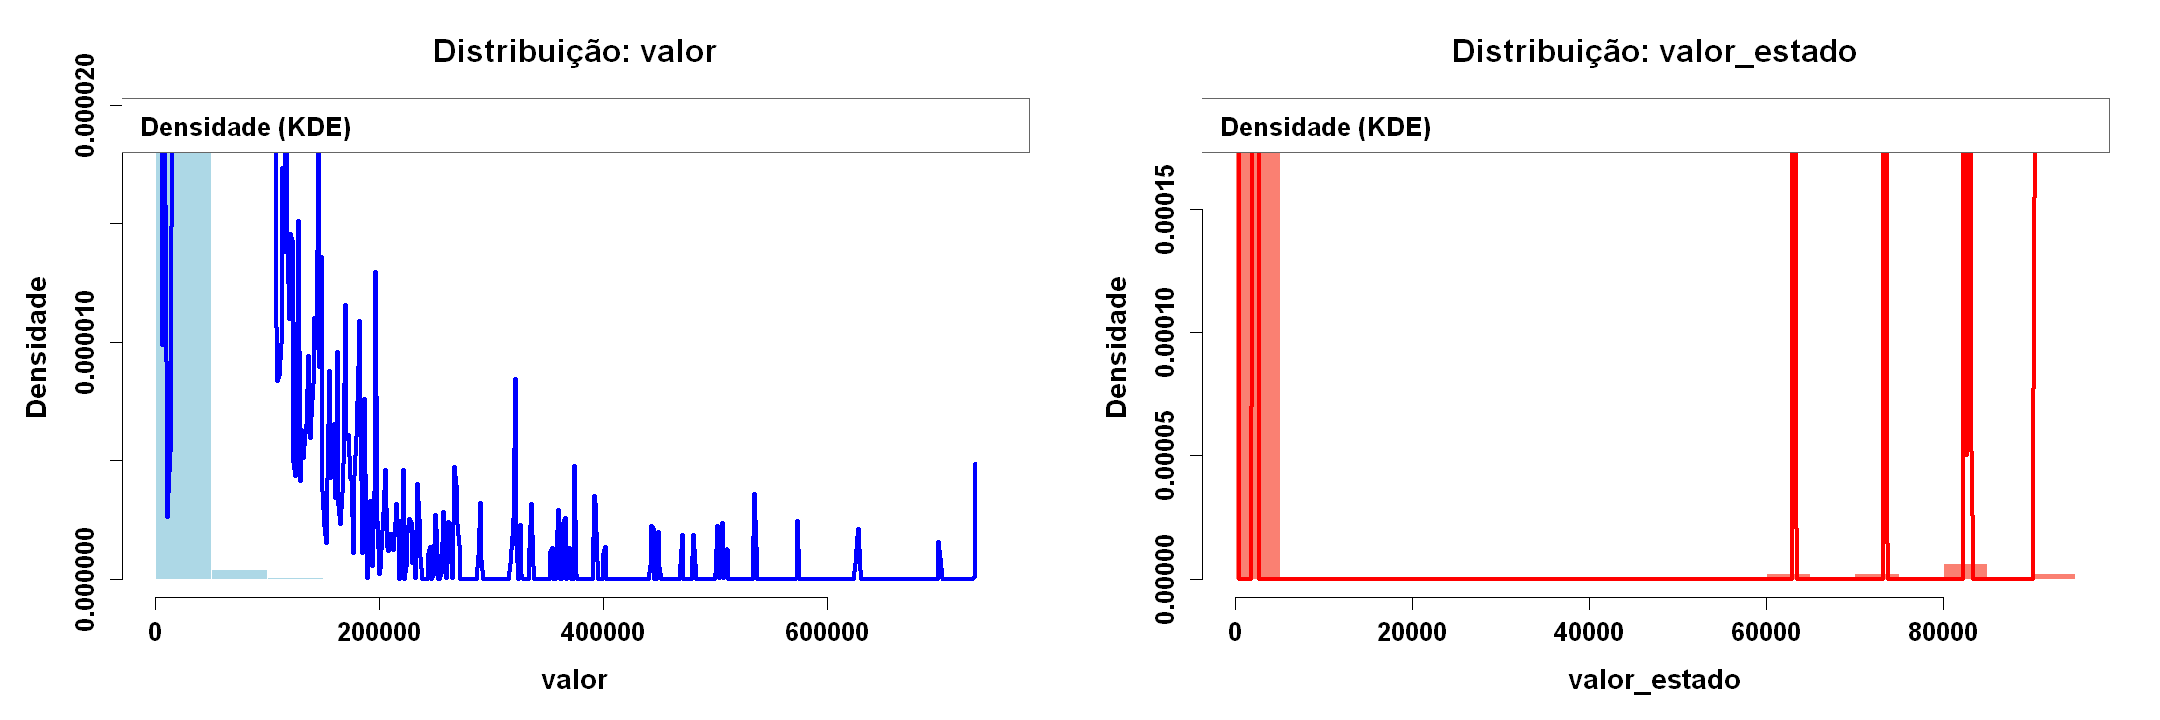

In [53]:
# ---------------------------------------------------------
# BLOCO 3: Histograma + KDE (Proporção Ampla, Fontes >= 14px em Negrito)
# ---------------------------------------------------------

# Desativa a notação científica nos eixos
options(scipen = 999)

# Proporção ampla da janela
options(repr.plot.width = 18, repr.plot.height = 6)

# Ajusta margens e define FONT = 2 (Negrito em todos os elementos gráficos)
par(mfrow = c(1, 2), mar = c(5, 5, 4, 2) + 0.1, font = 2, font.lab = 2, font.axis = 2, font.main = 2)

# --- Graph 1: Coluna valor ---
hist(df_limpo$valor_num, 
     probability = TRUE, 
     main = "Distribuição: valor", 
     xlab = "valor", 
     ylab = "Densidade",
     col = "lightblue", 
     border = "white",
     cex.main = 1.6,   # Título bem visível
     cex.lab = 1.4,    # Rótulos dos eixos (>= 14px)
     cex.axis = 1.3)   # Escalas numéricas (>= 14px)

# Linha da curva KDE grossa e destacada
lines(density(df_limpo$valor_num), col = "blue", lwd = 3.5)

# Legenda formatada em negrito
legend("topright", 
       legend = c("Densidade (KDE)"), 
       col = c("blue"), 
       lty = 1, 
       lwd = 3.5, 
       cex = 1.3, 
       text.font = 2, 
       bg = "white", 
       box.col = "gray40")

# --- Graph 2: Coluna valor_estado ---
hist(df_limpo$valor_estado_num, 
     probability = TRUE, 
     main = "Distribuição: valor_estado", 
     xlab = "valor_estado", 
     ylab = "Densidade",
     col = "salmon", 
     border = "white",
     cex.main = 1.6,   # Título bem visível
     cex.lab = 1.4,    # Rótulos dos eixos (>= 14px)
     cex.axis = 1.3)   # Escalas numéricas (>= 14px)

# Linha da curva KDE grossa e destacada
lines(density(df_limpo$valor_estado_num), col = "red", lwd = 3.5)

# Legenda formatada em negrito
legend("topright", 
       legend = c("Densidade (KDE)"), 
       col = c("red"), 
       lty = 1, 
       lwd = 3.5, 
       cex = 1.3, 
       text.font = 2, 
       bg = "white", 
       box.col = "gray40")

# Reseta o layout das janelas
par(mfrow = c(1, 1))

# --- Teste de Normalidade ---
set.seed(123)
amostra_val <- sample(df_limpo$valor_num, 5000)
amostra_est <- sample(df_limpo$valor_estado_num, 5000)

p_val <- shapiro.test(amostra_val)$p.value
p_est <- shapiro.test(amostra_est)$p.value

cat("\n--- ANÁLISE DE PARAMETRIA ---\n")
cat(sprintf("Coluna 'valor' -> Shapiro p-valor: %.5f (%s)\n", 
            p_val, ifelse(p_val > 0.05, "Paramétrica/Normal", "NÃO Paramétrica")))

cat(sprintf("Coluna 'valor_estado' -> Shapiro p-valor: %.5f (%s)\n", 
            p_est, ifelse(p_est > 0.05, "Paramétrica/Normal", "NÃO Paramétrica")))


=== ANÁLISE DE PARAMETRIA: RIQUEZA ===
Coluna 'valor' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)
Coluna 'valor_estado' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)



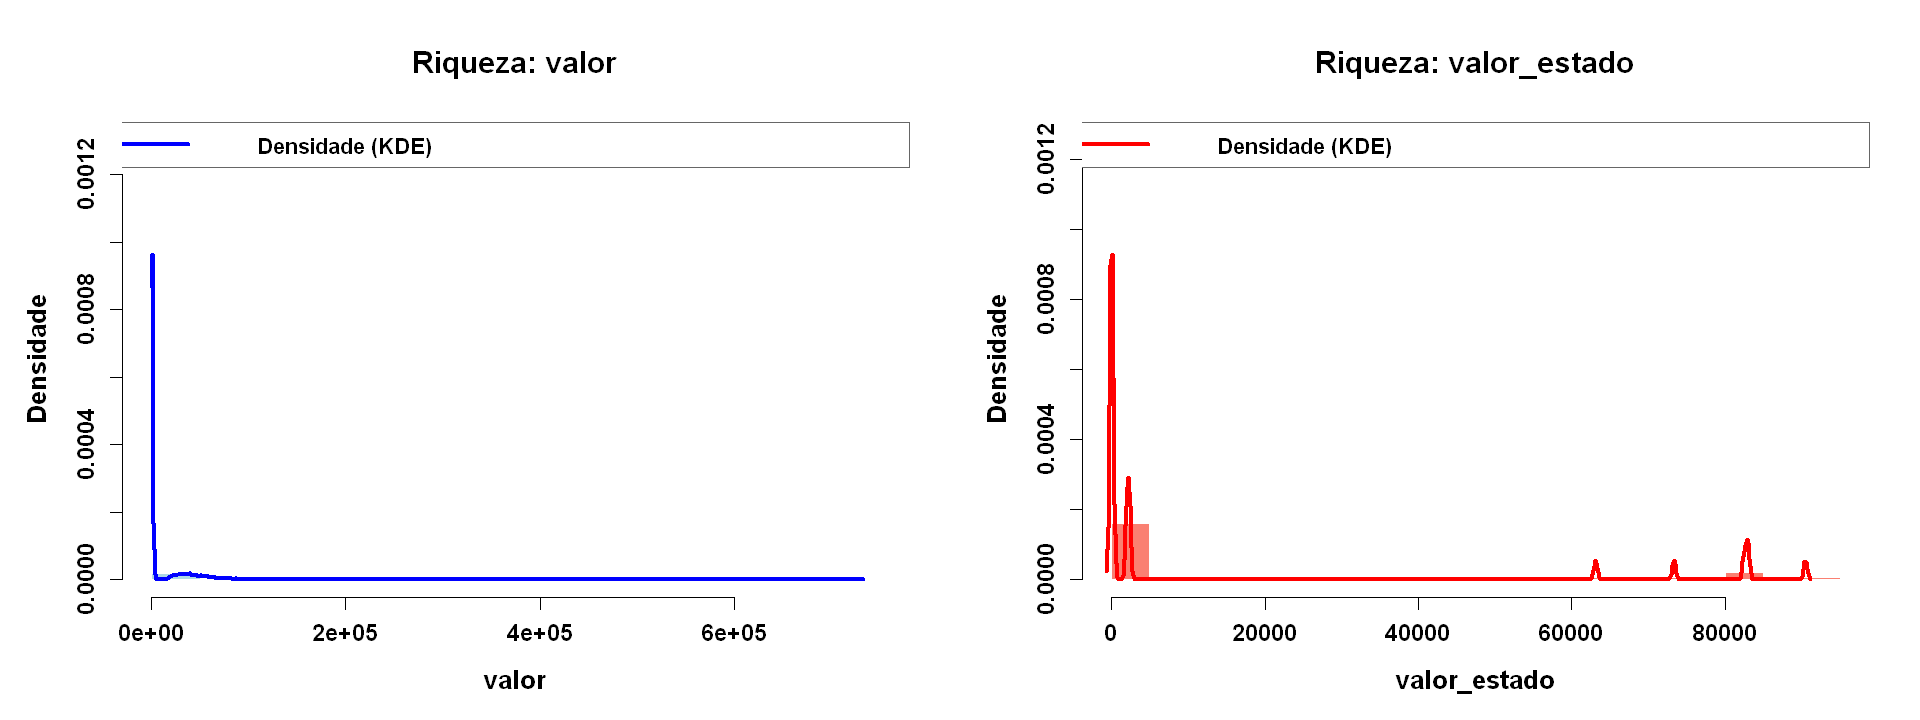


=== ANÁLISE DE PARAMETRIA: LONGEVIDADE ===
Coluna 'valor' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)
Coluna 'valor_estado' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)



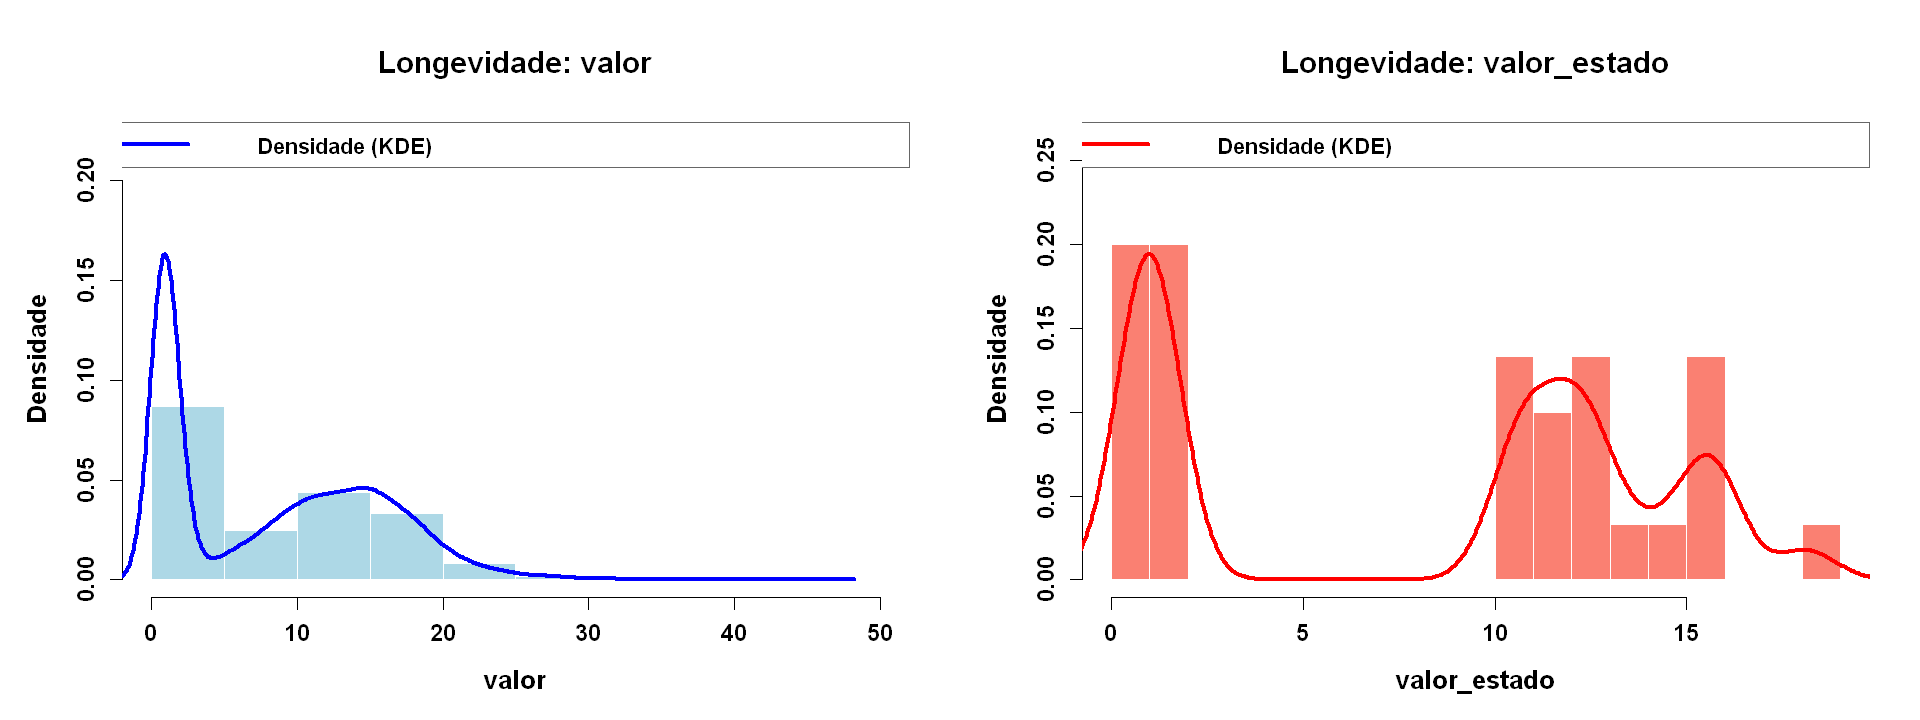


=== ANÁLISE DE PARAMETRIA: ESCOLARIDADE ===
Coluna 'valor' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)
Coluna 'valor_estado' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)



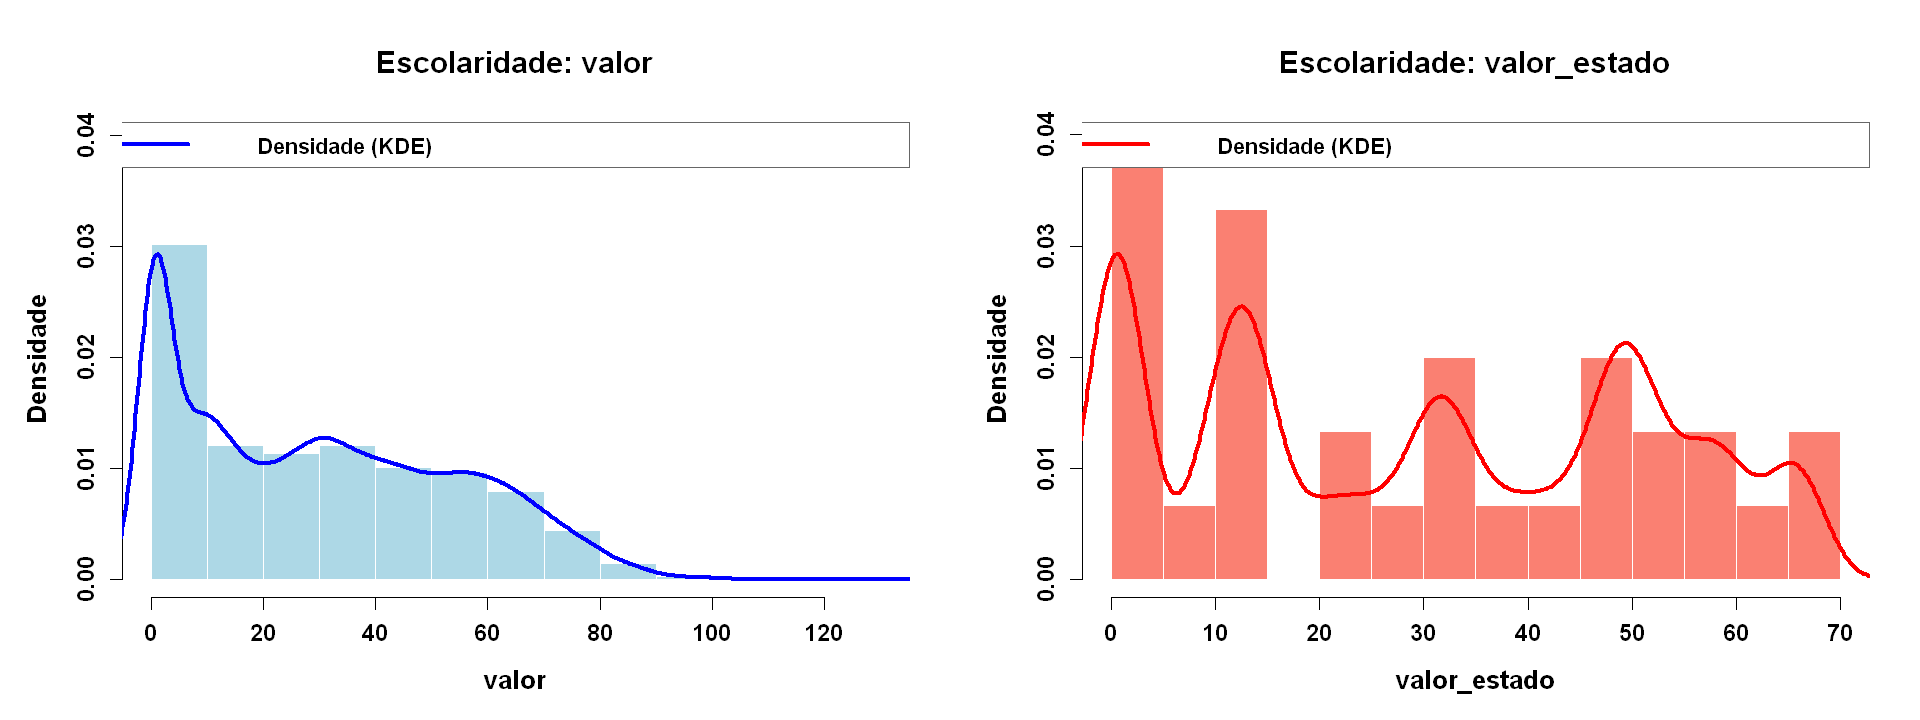


=== ANÁLISE DE PARAMETRIA: IPDM ===
Coluna 'valor' -> Shapiro p-valor: 0.00029 (NÃO Paramétrica)
Coluna 'valor_estado' -> Shapiro p-valor: 0.00000 (NÃO Paramétrica)



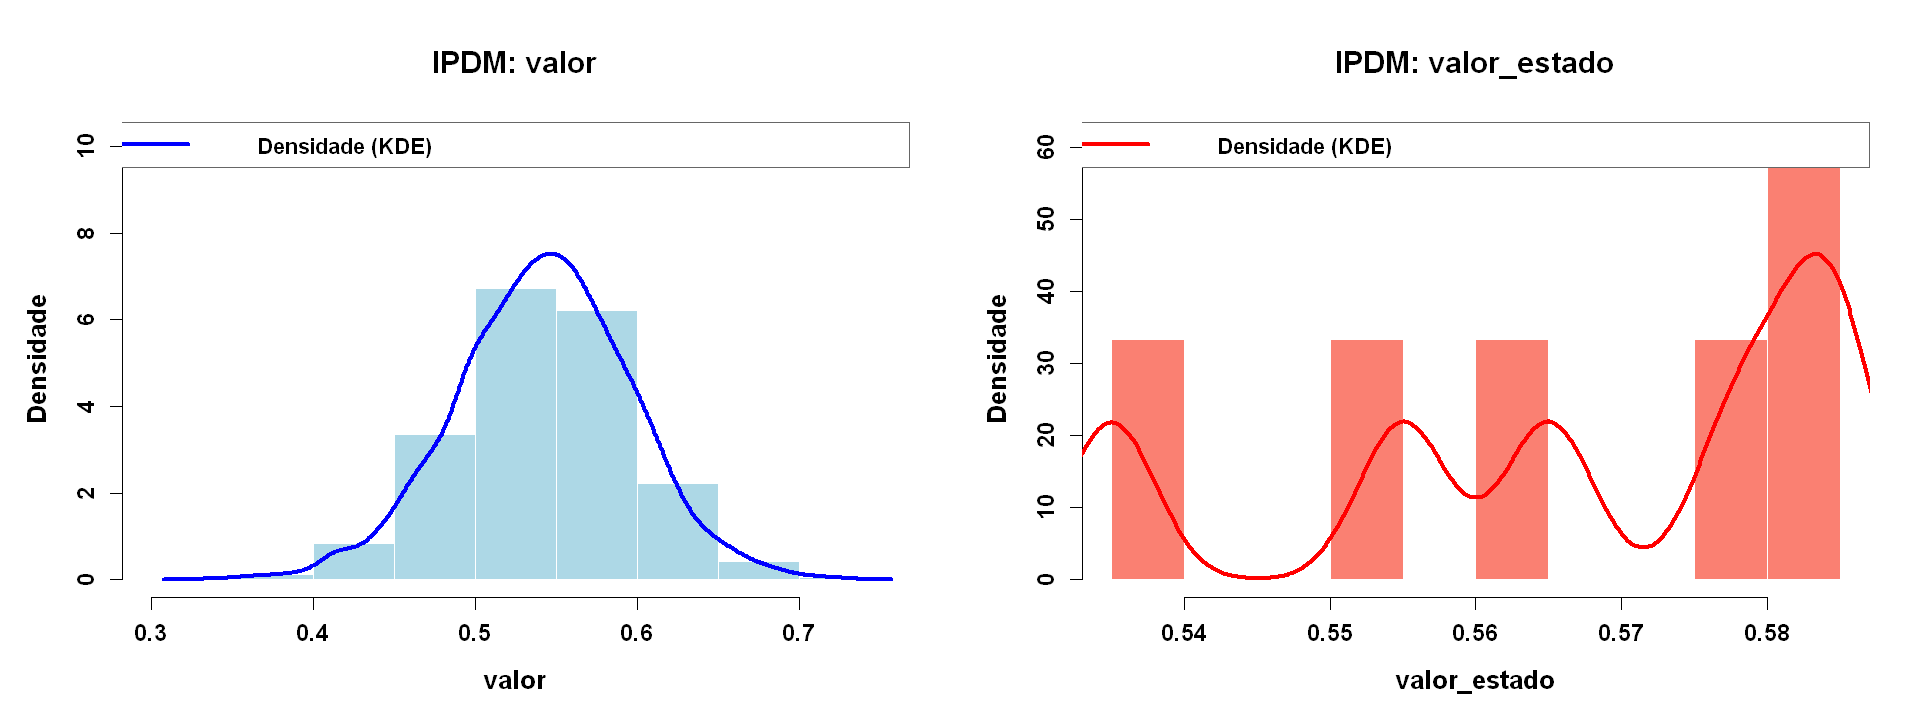

In [55]:
# ---------------------------------------------------------
# BLOCO 3: Histogramas + KDE Separados por Indicador
# ---------------------------------------------------------

# Configurações globais de exibição
options(scipen = 0) # Mantém notação padrão limpa
options(repr.plot.width = 16, repr.plot.height = 6)

# Lista com todos os tipos/indicadores da base
tipos_indicadores <- unique(df_limpo$tipo)

# Loop para gerar os gráficos individualmente para cada tipo
for (indicador in tipos_indicadores) {
  
  # Filtra a base para o indicador atual
  sub_df <- df_limpo[df_limpo$tipo == indicador, ]
  
  # Ajusta layout gráfico: 1 linha, 2 colunas e texto em NEGRITO
  par(mfrow = c(1, 2), mar = c(5, 5, 5, 2) + 0.1, 
      font = 2, font.lab = 2, font.axis = 2, font.main = 2)
  
  # --- Graph 1: Coluna valor ---
  dens_val <- density(sub_df$valor_num)
  
  hist(sub_df$valor_num, 
       probability = TRUE, 
       main = sprintf("%s: valor", indicador), 
       xlab = "valor", 
       ylab = "Densidade",
       col = "lightblue", 
       border = "white",
       ylim = c(0, max(dens_val$y) * 1.35), # Espaço no topo para legenda
       cex.main = 1.5, 
       cex.lab = 1.3, 
       cex.axis = 1.2)
  
  lines(dens_val, col = "blue", lwd = 3.5)
  
  legend("topright", 
         legend = c("Densidade (KDE)"), 
         col = "blue", 
         lty = 1, 
         lwd = 3.5, 
         cex = 1.1, 
         text.font = 2, 
         bg = "white", 
         box.col = "gray40")
  
  # --- Graph 2: Coluna valor_estado ---
  dens_est <- density(sub_df$valor_estado_num)
  
  hist(sub_df$valor_estado_num, 
       probability = TRUE, 
       main = sprintf("%s: valor_estado", indicador), 
       xlab = "valor_estado", 
       ylab = "Densidade",
       col = "salmon", 
       border = "white",
       ylim = c(0, max(dens_est$y) * 1.35), # Espaço no topo para legenda
       cex.main = 1.5, 
       cex.lab = 1.3, 
       cex.axis = 1.2)
  
  lines(dens_est, col = "red", lwd = 3.5)
  
  legend("topright", 
         legend = c("Densidade (KDE)"), 
         col = "red", 
         lty = 1, 
         lwd = 3.5, 
         cex = 1.1, 
         text.font = 2, 
         bg = "white", 
         box.col = "gray40")
  
  par(mfrow = c(1, 1))
  
  # --- Teste de Normalidade por Indicador ---
  set.seed(123)
  tam_amostra <- min(5000, nrow(sub_df))
  amostra_val <- sample(sub_df$valor_num, tam_amostra)
  amostra_est <- sample(sub_df$valor_estado_num, tam_amostra)
  
  p_val <- shapiro.test(amostra_val)$p.value
  p_est <- shapiro.test(amostra_est)$p.value
  
  cat(sprintf("\n=== ANÁLISE DE PARAMETRIA: %s ===\n", toupper(indicador)))
  cat(sprintf("Coluna 'valor' -> Shapiro p-valor: %.5f (%s)\n", 
              p_val, ifelse(p_val > 0.05, "Paramétrica/Normal", "NÃO Paramétrica")))
  cat(sprintf("Coluna 'valor_estado' -> Shapiro p-valor: %.5f (%s)\n\n", 
              p_est, ifelse(p_est > 0.05, "Paramétrica/Normal", "NÃO Paramétrica")))
}